In [29]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import WeightedRandomSampler
from torchvision import transforms
from torchvision.models import vit_b_16, ViT_B_16_Weights
from tqdm import tqdm

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [30]:
# ✅ Classes
SEASON_CLASSES = ['Spring', 'Summer', 'Autumn', 'Winter']

# ✅ Dataset
class PersonalColorDataset(Dataset):
    def __init__(self, csv_path, image_root, transform=None):
        self.data = pd.read_csv(csv_path)
        self.image_root = image_root
        self.transform = transform
        self.label_map = {season: idx for idx, season in enumerate(SEASON_CLASSES)}

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = os.path.join(self.image_root, row['season'], row['filename'])
        image = Image.open(img_path).convert('RGB')
        label = self.label_map[row['season']]

        if self.transform:
            image = self.transform(image)

        return image, label

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_val_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_val_loss is None:
            self.best_val_loss = val_loss
        elif val_loss < self.best_val_loss - self.min_delta:
            self.best_val_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

In [31]:
print(torch.cuda.max_memory_allocated() / 1e9, "GB")


0.64676096 GB


In [32]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.4, contrast=0.2, saturation=0.2),
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])


# Dataloaders
train_dataset = PersonalColorDataset(
    csv_path='combined_dataset/train.csv',
    image_root='combined_dataset/train',
    transform=train_transform
)

val_dataset = PersonalColorDataset(
    csv_path='combined_dataset/val.csv',
    image_root='combined_dataset/val',
    transform=val_transform
)

test_dataset = PersonalColorDataset(
    csv_path='combined_dataset/test.csv',
    image_root='combined_dataset/test',
    transform=val_transform
)


# ✅ Class Weights
df = pd.read_csv('combined_dataset/train.csv')
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(df['season']), y=df['season'])
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

# Calculate weights for each sample
label_to_idx = {label: idx for idx, label in enumerate(SEASON_CLASSES)}
labels = df['season'].map(label_to_idx)
class_sample_counts = labels.value_counts().sort_index().values
class_weights = 1. / class_sample_counts
sample_weights = [class_weights[label] for label in labels]

sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

# Replace train_loader
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

🔍 Class Distribution in Training Set:
season
Spring     992
Summer     964
Autumn    1047
Winter    1012
Name: count, dtype: int64


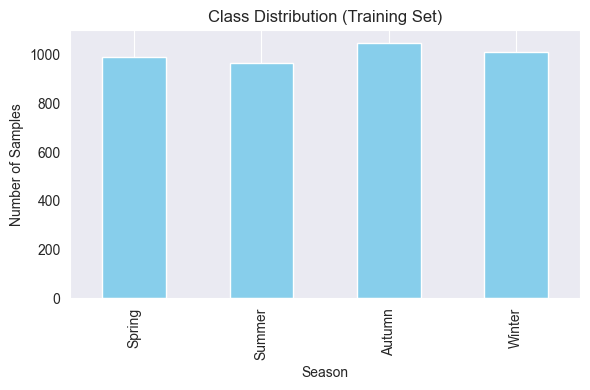

In [33]:
# Count class distribution
class_counts = df['season'].value_counts().reindex(SEASON_CLASSES)

# Print counts
print("🔍 Class Distribution in Training Set:")
print(class_counts)

# Plot as bar chart
plt.figure(figsize=(6, 4))
class_counts.plot(kind='bar', color='skyblue')
plt.title("Class Distribution (Training Set)")
plt.xlabel("Season")
plt.ylabel("Number of Samples")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [34]:
# ✅ Load ViT-B/16 with pretrained weights
weights = ViT_B_16_Weights.DEFAULT
model = vit_b_16(weights=weights)

# Replace head for 4-season classification
model.heads = nn.Sequential(
    nn.Linear(model.heads[0].in_features, 4)
)
model = model.to(device)

# ✅ Optimizer: AdamW
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)

# ✅ LR Scheduler: Cosine Annealing
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=1, eta_min=1e-5
)

# ✅ Loss (use class weights if needed)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Training function
def train_model(model, train_loader, val_loader, epochs):
    early_stopper = EarlyStopping(patience=5)
    history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_acc": []
    }

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct, total = 0, 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_acc = 100 * correct / total
        avg_loss = running_loss / len(train_loader)

        # Validation
        model.eval()
        val_loss = 0.0
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_acc = 100 * val_correct / val_total
        avg_val_loss = val_loss / len(val_loader)

        scheduler.step(avg_val_loss)

        # Save history
        history["train_loss"].append(avg_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(avg_val_loss)
        history["val_acc"].append(val_acc)

        # Early stopping
        if early_stopper(avg_val_loss):
            model.eval()
            print("Early stopping triggered.")
            break

        print(f"[{epoch+1}/{epochs}] Train Loss: {avg_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%, Val Loss: {avg_val_loss:.4f}\n")

    return history

# ✅ Train
history = train_model(model, train_loader, val_loader, epochs=30)

Epoch 1/30: 100%|██████████| 126/126 [02:31<00:00,  1.20s/it]


[1/30] Train Loss: 1.4392, Train Acc: 27.65%, Val Acc: 36.51%, Val Loss: 1.3335



Epoch 2/30: 100%|██████████| 126/126 [02:36<00:00,  1.24s/it]


[2/30] Train Loss: 1.3590, Train Acc: 31.66%, Val Acc: 35.69%, Val Loss: 1.3298



Epoch 3/30: 100%|██████████| 126/126 [02:36<00:00,  1.24s/it]


...

[28/30] Train Loss: 1.2054, Train Acc: 44.23%, Val Acc: 46.77%, Val Loss: 1.1939



Epoch 29/30: 100%|██████████| 126/126 [02:38<00:00,  1.26s/it]


[29/30] Train Loss: 1.1875, Train Acc: 46.33%, Val Acc: 44.62%, Val Loss: 1.2035



Epoch 30/30: 100%|██████████| 126/126 [02:38<00:00,  1.26s/it]


[30/30] Train Loss: 1.2036, Train Acc: 45.11%, Val Acc: 41.95%, Val Loss: 1.2064



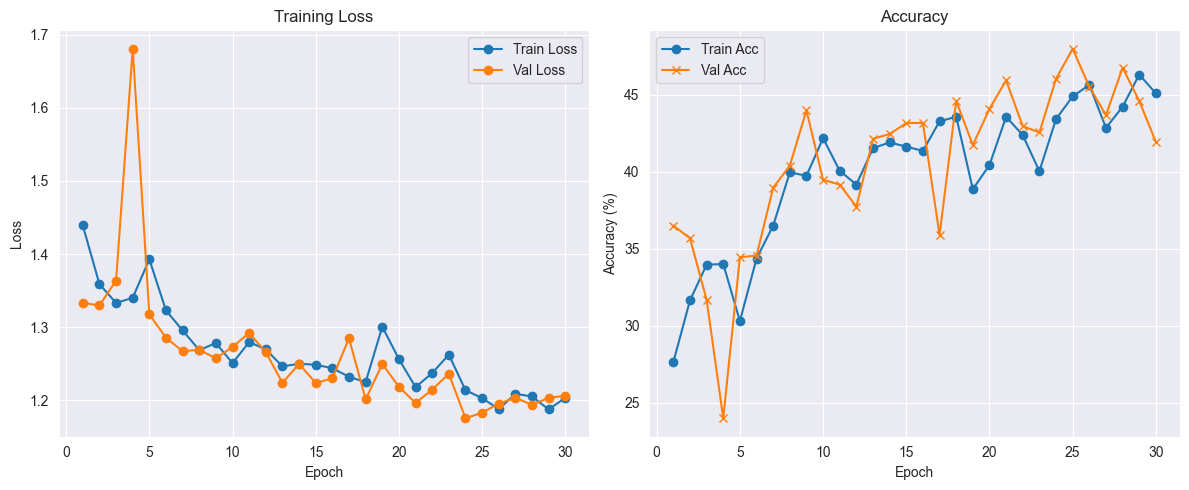

In [37]:
def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label='Train Loss', marker='o')
    plt.plot(epochs, history["val_loss"], label='Val Loss', marker='o')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label='Train Acc', marker='o')
    plt.plot(epochs, history["val_acc"], label='Val Acc', marker='x')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

Test Accuracy: 48.07%

Classification Report:
              precision    recall  f1-score   support

      Spring       0.45      0.57      0.50       248
      Summer       0.49      0.41      0.44       231
      Autumn       0.44      0.71      0.54       304
      Winter       0.81      0.23      0.36       303

    accuracy                           0.48      1086
   macro avg       0.55      0.48      0.46      1086
weighted avg       0.56      0.48      0.46      1086



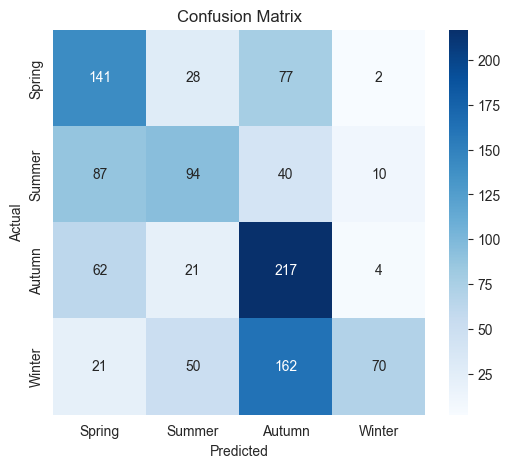

In [38]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Accuracy
    total = len(all_labels)
    correct = sum(p == l for p, l in zip(all_preds, all_labels))
    acc = 100 * correct / total
    print(f"Test Accuracy: {acc:.2f}%")

    # Classification report
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=SEASON_CLASSES))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=SEASON_CLASSES, yticklabels=SEASON_CLASSES)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

evaluate_model(model, test_loader)